#1. 데이터 수집하기
* 1975-2025년 자장면 물가지수
* 2020년 자장면 재료 가격

1.1 데이터 수집하기

In [ ]:
# 파일업로드
from google.colab import files
uploaded = files.upload( )

Saving 자장면소비자물가지수(1975-2025).csv to 자장면소비자물가지수(1975-2025).csv


1.2 데이터프레임에 저장하기

In [ ]:
import pandas as pd
df=pd.read_csv('/content/자장면소비자물가지수(1975-2025).csv',  encoding='cp949')
df.head()

,연도,양파,돼지고기,밀가루,자장면
0,1975,6.08,8.36,9.75,2.89
1,1976,7.14,10.89,10.37,3.19
2,1977,5.42,11.24,10.15,4.08
3,1978,11.37,15.10,9.96,4.28
4,1979,11.32,14.59,10.50,5.82


#2 데이터 탐색과 전처리하기
2.1 데이터 둘러보기

In [ ]:
#데이터 속성 확인하기
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연도      51 non-null     int64  
 1   양파      51 non-null     float64
 2   돼지고기    51 non-null     float64
 3   밀가루     51 non-null     float64
 4   자장면     51 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 2.1 KB


In [ ]:
# df의 모든 값이 NaN인 행 삭제(만약 데이터프레임에 결측치가 있으면 결측치를 모두 삭제한다.)
df = df.dropna(how='all').reset_index(drop=True)
display(df)

,연도,양파,돼지고기,밀가루,자장면
0,1975,6.08,8.36,9.75,2.89
1,1976,7.14,10.89,10.37,3.19
2,1977,5.42,11.24,10.15,4.08
3,1978,11.37,15.10,9.96,4.28
4,1979,11.32,14.59,10.50,5.82
5,1980,14.73,17.12,15.64,7.29
6,1981,23.63,28.71,20.18,9.86
7,1982,20.02,28.85,19.69,11.05
8,1983,12.26,26.57,18.40,11.02
9,1984,26.02,22.68,18.20,11.91


In [ ]:
#물가지수 통계 값 확인하기
df.describe()

,연도,양파,돼지고기,밀가루,자장면
count,51.000000,51.000000,51.00000,51.000000,51.000000
mean,2000.000000,51.256078,55.25451,56.865490,52.792745
std,14.866069,32.463029,34.05577,40.402304,37.197916
min,1975.000000,5.420000,8.36000,9.750000,2.890000
25%,1987.500000,21.745000,28.78000,20.265000,15.000000
50%,2000.000000,43.580000,40.31000,43.980000,50.790000
75%,2012.500000,73.860000,84.63000,99.170000,81.645000
max,2025.000000,110.110000,128.13000,138.050000,133.520000


#2.2 데이터 전처리하기



In [ ]:
# 2020년도 자장면 재료 가격
price2020=[3734, 2032, 1356, 5195]   #양파, 돼지고기,밀가루, 자장면 가격

자장면 재료별 물가지수를 가격 데이터로 변환

In [ ]:
df['양파 가격']=round(df['양파']*price2020[0]/100,2)
df['돼지고기 가격']=round(df['돼지고기']*price2020[1]/100,2)
df['밀가루 가격']=round(df['밀가루']*price2020[2]/100,2)
df['자장면 가격']=round(df['자장면']*price2020[3]/100,2)

In [ ]:
# 자장면 재료 가격 확인하기
df[44:51]              # 2020년 기준년도의 소비자 물가지수는 100이다

,연도,양파,돼지고기,밀가루,자장면,양파 가격,돼지고기 가격,밀가루 가격,자장면 가격
44,2019,68.75,90.31,101.07,98.59,2567.12,1835.10,1370.51,5121.75
45,2020,100.00,100.00,100.00,100.00,3734.00,2032.00,1356.00,5195.00
46,2021,103.56,111.11,100.67,103.07,3866.93,2257.76,1365.09,5354.49
47,2022,94.42,120.09,128.83,114.20,3525.64,2440.23,1746.93,5932.69
48,2023,109.06,118.33,138.05,122.42,4072.30,2404.47,1871.96,6359.72
49,2024,103.31,120.57,135.90,126.38,3857.60,2449.98,1842.80,6565.44
50,2025,109.74,128.13,135.64,133.52,4097.69,2603.60,1839.28,6936.36


#2.3 탐색적 데이터 분석하기

In [ ]:
df2=df.iloc[:,[0,5,6,7,8]]
df2.head()

,연도,양파 가격,돼지고기 가격,밀가루 가격,자장면 가격
0,1975,227.03,169.88,132.21,150.14
1,1976,266.61,221.28,140.62,165.72
2,1977,202.38,228.40,137.63,211.96
3,1978,424.56,306.83,135.06,222.35
4,1979,422.69,296.47,142.38,302.35


In [ ]:
#속성간 상관관계 출력
df2.corr()

,연도,양파 가격,돼지고기 가격,밀가루 가격,자장면 가격
연도,1.000000,0.954821,0.961268,0.956064,0.988053
양파 가격,0.954821,1.000000,0.948255,0.942277,0.956605
돼지고기 가격,0.961268,0.948255,1.000000,0.975701,0.973636
밀가루 가격,0.956064,0.942277,0.975701,1.000000,0.973582
자장면 가격,0.988053,0.956605,0.973636,0.973582,1.000000


In [ ]:
#한글 라이브러리 설치하기
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 72.8 MB/s eta 0:00:00


<Axes: >

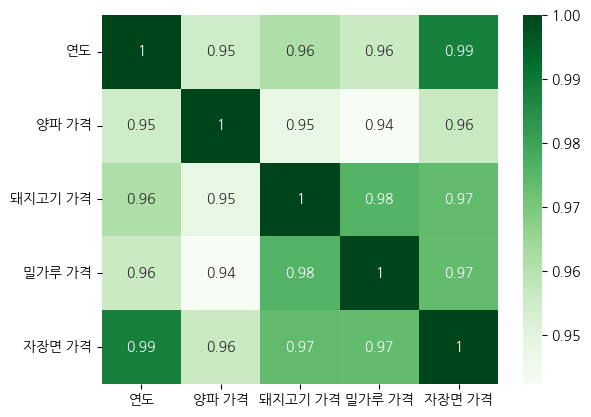

In [ ]:
#히트맵으로 상관관계 시각화하기
import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df2.corr(),annot=True, cmap='Greens')   #히트맵 출력

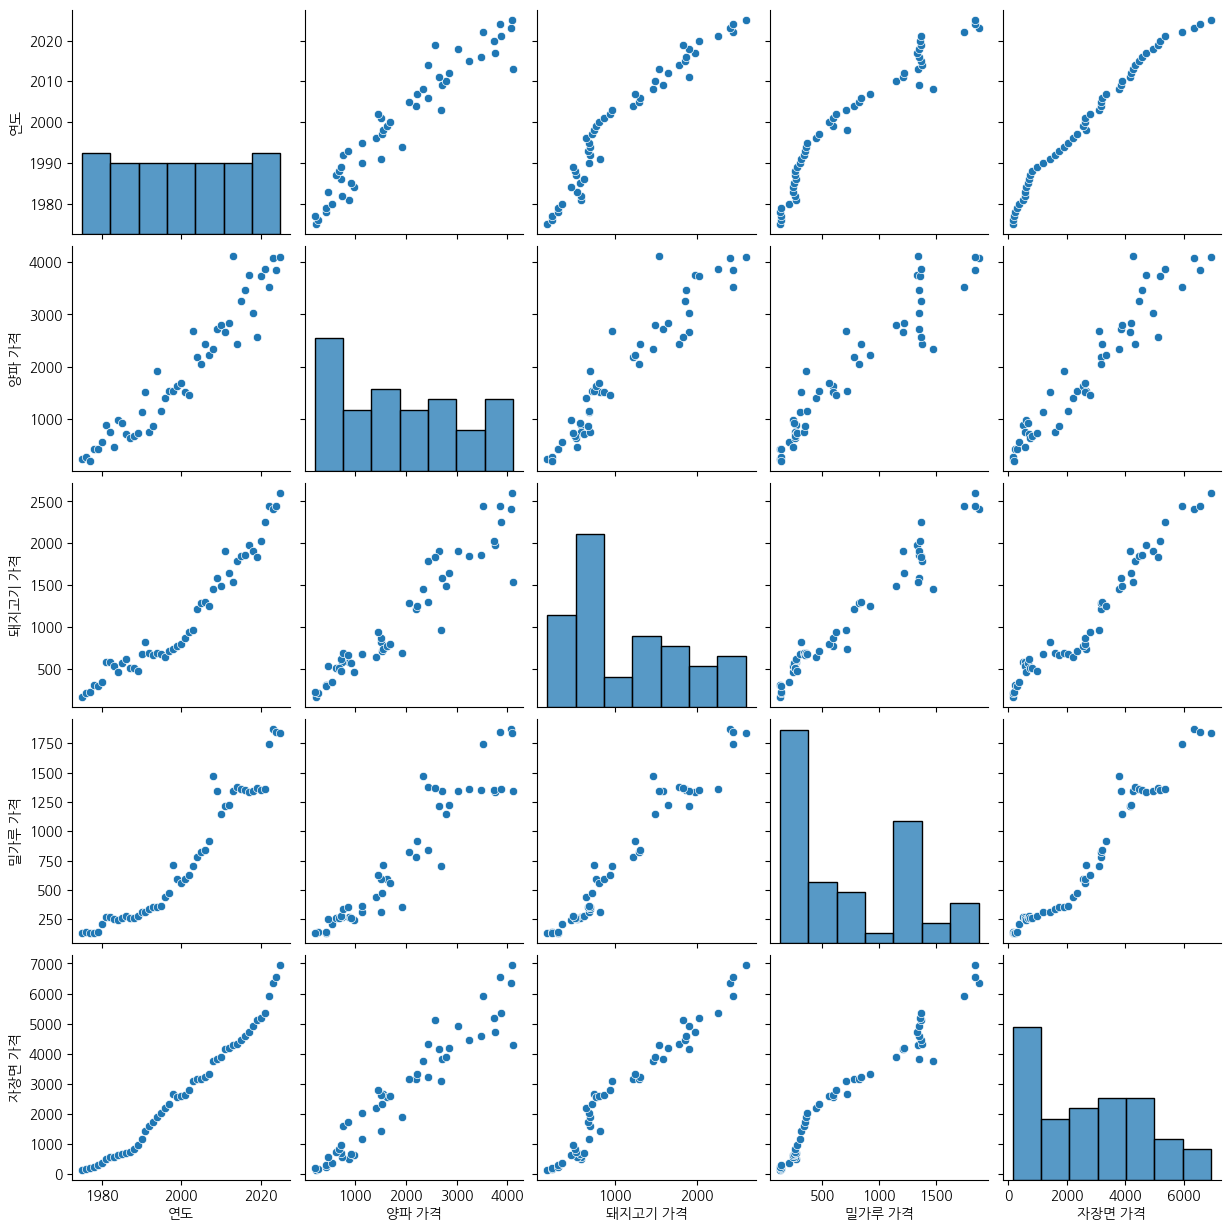

In [ ]:
# pairplot으로 시각화하기
sns.pairplot(df2)

2.4 독립변수와 종속변수 선정하기

In [ ]:

X=df2.iloc[:,0:4]   # 자장면 재료 가격 데이터를 X에 저장
y=df2.iloc[:,4]     # 자장면 가격 데이터를 y데이터에 저장
X.head()

,연도,양파 가격,돼지고기 가격,밀가루 가격
0,1975,227.03,169.88,132.21
1,1976,266.61,221.28,140.62
2,1977,202.38,228.40,137.63
3,1978,424.56,306.83,135.06
4,1979,422.69,296.47,142.38


#2.5 훈련 데이터와 테스트 데이터 분할하기

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.3, random_state=42)

In [ ]:
X_train.head()

,연도,양파 가격,돼지고기 가격,밀가루 가격
36,2011,2656.37,1909.67,1212.54
33,2008,2333.75,1461.62,1474.38
19,1994,1924.88,695.76,356.09
48,2023,4072.30,2404.47,1871.96
15,1990,1126.55,684.78,310.12


#3.모델 생성하기
3.1 모델 학습하기

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

3.2 회귀계수와 절편 확인하기

In [ ]:
print(model.coef_, model.intercept_)   # coef_ : 회귀계수, intercept_ : 절편

[8.42261067e+01 3.16468850e-02 3.39633149e-01 7.21458264e-01] -166694.59840136988


In [ ]:
for i in range(4):
  print("w%d = %.3f"%(i+1,model.coef_[i]))
print("b = %.3f"%(model.intercept_))

w1 = 84.226
w2 = 0.032
w3 = 0.340
w4 = 0.721
b = -166694.598


연도를 x1, 양파 가격을 x2, 돼지고기 가격을 x3, 밀가루 가격을 x4라고 할 때 자장면 가격(y)를 예측하는 모델의 식은 다음과 같다.

$$ y= 84.226x_{1}+0.032x_{2} +0.340x_{3} + 0.721x_{3}-166694.598 $$





3.3 모델 성능 확인하기

In [ ]:
print('훈련 데이터로 학습한 모델의 성능(R2):', model.score(X_train, y_train))

훈련 데이터로 학습한 모델의 성능(R2): 0.983837468075969


# 4. 모델 평가 및 예측하기

4.1 모델 성능 평가하기

In [ ]:
# 테스트 데이터로 모델 성능 평가
# Clean X_test and y_test for evaluation
print('테스트 데이터로 모델의 성능(R2) 평가:', model.score(X_test, y_test))

테스트 데이터로 모델의 성능(R2) 평가: 0.9903761365835748



* mean_absolute_error 오차들의 절댓값 합  
* mean_squared_error 오차제곱들의 합  
* r2_score 결정계수

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_pred=model.predict(X_test)

print('Mean squared error :', mean_squared_error(y_pred, y_test))
print('Mean absolute error :', mean_absolute_error(y_pred, y_test))
print('R2 score : ', r2_score(y_test, y_pred))

Mean squared error : 42785.722894464605
Mean absolute error : 165.42217005998342
R2 score :  0.9903761365835748


4.2 모델 예측하기

In [ ]:
y_pred=model.predict(X_test)
print('실제값:')
print(y_test[:5])
print('예측값:', y_pred[:5])

실제값:
43    4934.21
40    4452.12
46    5354.49
12     733.53
24    2569.45
Name: 자장면 가격, dtype: float64
예측값: [4990.24873179 4737.44789408 5400.40521355 1050.31289288 2414.85608062]


#5. 모델 활용 문제해결하기

In [ ]:
# 새로운 데이터 업로드하기
from google.colab import files
uploaded = files.upload( )

Saving new_data(v2).csv to new_data(v2).csv


새로운 데이터 불러오기

In [ ]:
df_new=pd.read_csv('new_data(v2).csv', encoding='cp949')
df_new

,연도,양파 가격,돼지고기 가격,밀가루 가격
0,2030,4249.57,2465.18,1828.10
1,2040,5028.12,2912.65,2180.44
2,2050,5806.68,3360.12,2532.78


In [ ]:
print(model.predict(df_new))

[6575.03863697 7848.11263681 9121.18695313]
